# Relationship Between Contract Type and Financing Amount

Analyzing financing amounts by contract category helps identify the financial scale associated with different financing products.

This section compares average financing amounts across contract types.

# Exploratory Data Analysis of Synthetic Financing Contracts

## Objective

This notebook analyzes the structured dataset generated in Notebook 1.

The goal is to identify patterns, trends, and insights from the extracted contract information.

Areas of analysis include:

- Contract Type Distribution
- Borrower Analysis
- Financing Amount Analysis
- Clause Analysis
- Obligation Analysis

The findings will help understand the characteristics of the contract dataset and prepare the data for future machine learning applications.

## Dataset Overview

In [1]:
# Load Libraries and Dataset
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/contracts.csv")
df.head()

,contract_type,borrower,lender,amount,clauses,jurisdiction,obligations,file
0,HEALTH FINANCING AGREEMENT,Julia Miller,FINANCIAL BANK OF AMERICA Inc.,"$42,751.00.","['PURPOSE', 'TERM', 'PAYMENT', 'GUARANTEES', '...","New York, NY",['CLAUSE THREE – PAYMENT: The BORROWER shall p...,Contract_16.pdf
1,MOTORCYCLE FINANCING AGREEMENT,Patricia Hall,FINANCIAL BANK OF AMERICA Inc.,"$36,160.00.","['PURPOSE', 'TERM', 'PAYMENT', 'GUARANTEES', '...","New York, NY",['CLAUSE THREE – PAYMENT: The BORROWER shall p...,Contract_4.pdf
2,HEALTH FINANCING AGREEMENT,Patricia Hall,FINANCIAL BANK OF AMERICA Inc.,"$40,267.00.","['PURPOSE', 'TERM', 'PAYMENT', 'GUARANTEES', '...","New York, NY",['CLAUSE THREE – PAYMENT: The BORROWER shall p...,Contract_5.pdf
3,STUDENT LOAN AGREEMENT,Richard Taylor,FINANCIAL BANK OF AMERICA Inc.,"$56,424.00.","['PURPOSE', 'TERM', 'PAYMENT', 'GUARANTEES', '...","New York, NY",['CLAUSE THREE – PAYMENT: The BORROWER shall p...,Contract_17.pdf
4,HEALTH FINANCING AGREEMENT,Mary Johnson,FINANCIAL BANK OF AMERICA Inc.,"$48,720.00.","['PURPOSE', 'TERM', 'PAYMENT', 'GUARANTEES', '...","New York, NY",['CLAUSE THREE – PAYMENT: The BORROWER shall p...,Contract_7.pdf


# Dataset Inspection

Before performing analysis, we inspect the dataset structure, dimensions, and data types.

This helps identify missing values and verify dataset integrity.

In [2]:
df.shape

(30, 8)

In [3]:
df.info


<bound method DataFrame.info of                       contract_type        borrower  \
0        HEALTH FINANCING AGREEMENT    Julia Miller   
1    MOTORCYCLE FINANCING AGREEMENT   Patricia Hall   
2        HEALTH FINANCING AGREEMENT   Patricia Hall   
3            STUDENT LOAN AGREEMENT  Richard Taylor   
4        HEALTH FINANCING AGREEMENT    Mary Johnson   
5    MOTORCYCLE FINANCING AGREEMENT   Patricia Hall   
6        HEALTH FINANCING AGREEMENT    Peter Wilson   
7   REAL ESTATE FINANCING AGREEMENT   Patricia Hall   
8   REAL ESTATE FINANCING AGREEMENT    Carlos Brown   
9        HEALTH FINANCING AGREEMENT    Julia Miller   
10   MOTORCYCLE FINANCING AGREEMENT    Julia Miller   
11          CAR FINANCING AGREEMENT     Emily Clark   
12  REAL ESTATE FINANCING AGREEMENT     Emily Clark   
13       HEALTH FINANCING AGREEMENT    Julia Miller   
14          CAR FINANCING AGREEMENT    Peter Wilson   
15          CAR FINANCING AGREEMENT    Carlos Brown   
16          CAR FINANCING AGREEME

In [4]:
df.describe(include="all")

,contract_type,borrower,lender,amount,clauses,jurisdiction,obligations,file
count,30,30,30,30,30,30,30,30
unique,5,10,1,30,1,1,1,30
top,CAR FINANCING AGREEMENT,Julia Miller,FINANCIAL BANK OF AMERICA Inc.,"$42,751.00.","['PURPOSE', 'TERM', 'PAYMENT', 'GUARANTEES', '...","New York, NY",['CLAUSE THREE – PAYMENT: The BORROWER shall p...,Contract_16.pdf
freq,10,7,30,1,30,30,30,1


# Contract Type Analysis

Contract types represent the primary category of financing agreement.

Understanding their distribution helps identify dominant contract categories within the dataset.

In [5]:
df["contract_type"].value_counts()

contract_type
CAR FINANCING AGREEMENT            10
HEALTH FINANCING AGREEMENT          9
REAL ESTATE FINANCING AGREEMENT     5
MOTORCYCLE FINANCING AGREEMENT      4
STUDENT LOAN AGREEMENT              2
Name: count, dtype: int64

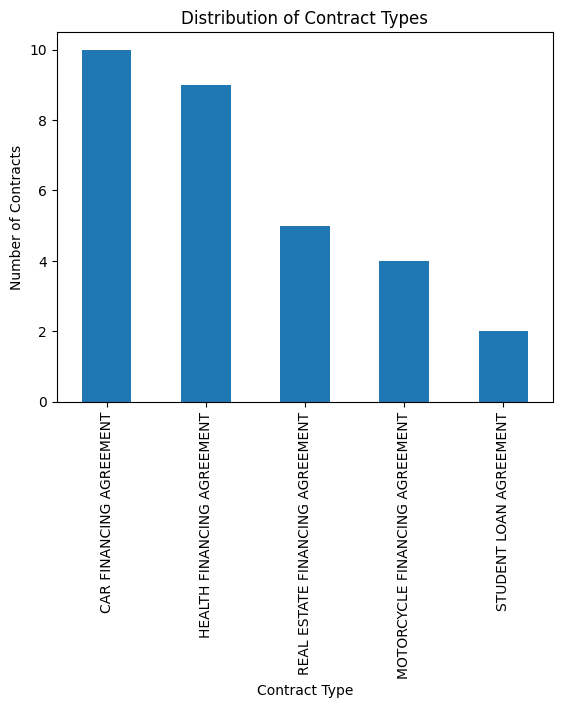

In [6]:
df["contract_type"].value_counts().plot(kind="bar")

plt.title("Distribution of Contract Types")
plt.xlabel("Contract Type")
plt.ylabel("Number of Contracts")

plt.show()

# Borrower Analysis

This section examines borrower frequency and borrower diversity across the dataset.

In [7]:
df["borrower"].value_counts()

borrower
Julia Miller      7
Carlos Brown      5
Patricia Hall     4
Emily Clark       4
John Smith        3
Richard Taylor    2
Peter Wilson      2
Mary Johnson      1
Anna Davis        1
Michael Lewis     1
Name: count, dtype: int64

In [8]:
df["borrower"].nunique()

10

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   contract_type  30 non-null     object
 1   borrower       30 non-null     object
 2   lender         30 non-null     object
 3   amount         30 non-null     object
 4   clauses        30 non-null     object
 5   jurisdiction   30 non-null     object
 6   obligations    30 non-null     object
 7   file           30 non-null     object
dtypes: object(8)
memory usage: 2.0+ KB


In [10]:
df["amount"].head(10)

0       $42,751.00.
1       $36,160.00.
2       $40,267.00.
3       $56,424.00.
4       $48,720.00.
5       $33,310.00.
6       $42,398.00.
7    $1,202,267.00.
8    $1,203,432.00.
9       $47,142.00.
Name: amount, dtype: object

# Financing Amount Analysis

### Objective

Currently, the values are stored as text strings and must be converted into numerical format before statistical analysis can be performed.

This section focuses on:

- Data Cleaning
- Amount Distribution
- Average Financing Amount
- Minimum Financing Amount
- Maximum Financing Amount
- Financing Trends Across Contract Types

Understanding the financing amounts helps identify the scale and characteristics of different financing agreements.

In [11]:
# Clean Amount Column
df["amount_clean"] = (
    df["amount"]
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.rstrip(".")
)

df[["amount", "amount_clean"]].head()

,amount,amount_clean
0,"$42,751.00.",42751.00
1,"$36,160.00.",36160.00
2,"$40,267.00.",40267.00
3,"$56,424.00.",56424.00
4,"$48,720.00.",48720.00


In [12]:
df["amount_clean"] = pd.to_numeric(df["amount_clean"])

df["amount_clean"].dtype

dtype('float64')

## Descriptive Statistics of Financing Amounts

After converting financing amounts into numerical format, statistical analysis can be performed.

Key statistics include:

- Mean (Average)
- Median
- Minimum
- Maximum
- Standard Deviation

These metrics provide insights into the overall financial scale of the contracts.

In [13]:
df["amount_clean"].describe()

count    3.000000e+01
mean     2.488919e+05
std      4.331995e+05
min      3.331000e+04
25%      4.312750e+04
50%      6.780500e+04
75%      8.315925e+04
max      1.203432e+06
Name: amount_clean, dtype: float64

In [14]:
print("Average Amount:", df["amount_clean"].mean())
print("Maximum Amount:", df["amount_clean"].max())
print("Minimum Amount:", df["amount_clean"].min())

Average Amount: 248891.86666666667
Maximum Amount: 1203432.0
Minimum Amount: 33310.0


## Financing Amount Distribution

Visualizing the financing amount distribution helps identify:

- Common financing ranges
- Potential outliers
- Data spread
- Distribution characteristics

Histograms are commonly used for numerical data exploration.

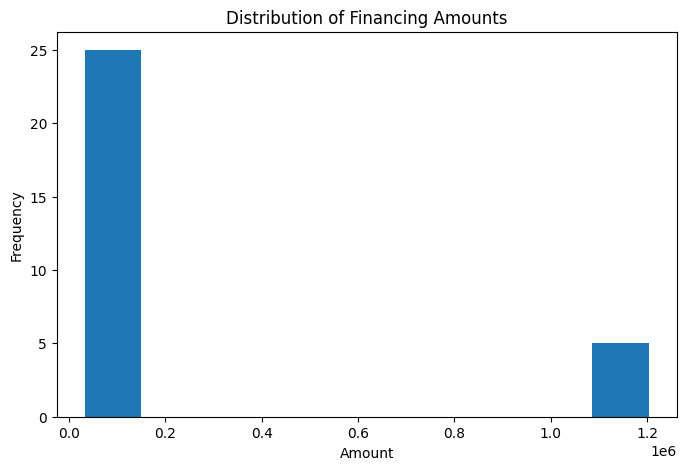

In [15]:
plt.figure(figsize=(8,5))

plt.hist(df["amount_clean"], bins=10)

plt.title("Distribution of Financing Amounts")
plt.xlabel("Amount")
plt.ylabel("Frequency")

plt.show()

## Financing Amount by Contract Type

Different financing products are expected to have different financing ranges.

This section compares average financing amounts across contract categories to identify patterns and differences.

In [16]:
df.groupby("contract_type")["amount_clean"].mean().sort_values(ascending=False)

contract_type
REAL ESTATE FINANCING AGREEMENT    1200491.00
CAR FINANCING AGREEMENT              80566.90
STUDENT LOAN AGREEMENT               58244.00
HEALTH FINANCING AGREEMENT           44207.00
MOTORCYCLE FINANCING AGREEMENT       36070.25
Name: amount_clean, dtype: float64

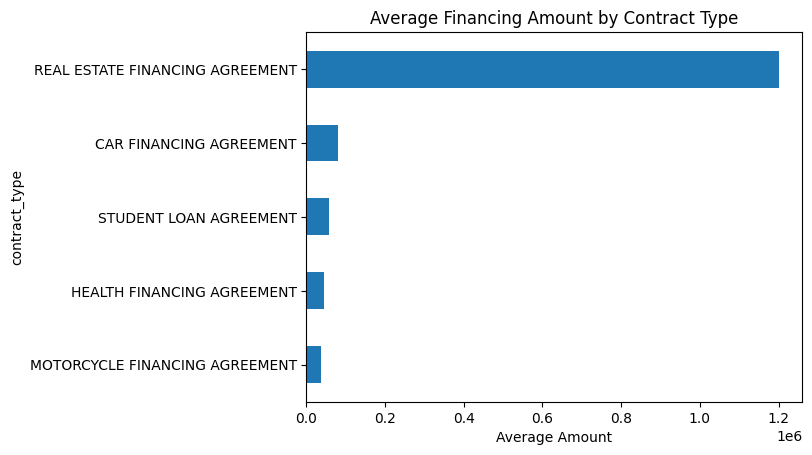

In [17]:
df.groupby("contract_type")["amount_clean"].mean().sort_values().plot(
    kind="barh"
)

plt.title("Average Financing Amount by Contract Type")
plt.xlabel("Average Amount")

plt.show()

# Clause Analysis

### Objective

analyzing clause patterns helps determine:

- Contract consistency
- Common legal provisions
- Template similarities
- Legal structure across financing products

This section investigates the clause composition of the contracts.

In [18]:
df["clauses"].iloc[0]

"['PURPOSE', 'TERM', 'PAYMENT', 'GUARANTEES', 'INSURANCE', 'DEFAULT', 'TERMINATION', 'JURISDICTION']"

In [19]:
all_clauses = []

for clause_list in df["clauses"]:
    all_clauses.extend(clause_list)

all_clauses[:20]

['[',
 "'",
 'P',
 'U',
 'R',
 'P',
 'O',
 'S',
 'E',
 "'",
 ',',
 ' ',
 "'",
 'T',
 'E',
 'R',
 'M',
 "'",
 ',',
 ' ']

In [20]:
from collections import Counter

clause_counts = Counter(all_clauses)

clause_counts

Counter({"'": 480,
         'E': 240,
         ',': 210,
         ' ': 210,
         'T': 210,
         'N': 210,
         'R': 180,
         'A': 180,
         'I': 180,
         'U': 150,
         'S': 120,
         'P': 90,
         'O': 90,
         'M': 90,
         'C': 60,
         'D': 60,
         '[': 30,
         'Y': 30,
         'G': 30,
         'F': 30,
         'L': 30,
         'J': 30,
         ']': 30})

In [21]:
clause_df = pd.DataFrame(
    clause_counts.items(),
    columns=["Clause", "Count"]
)

clause_df.sort_values("Count", ascending=False)

,Clause,Count
1,',480
7,E,240
9,,210
14,N,210
8,",",210
10,T,210
16,I,180
4,R,180
12,A,180
3,U,150


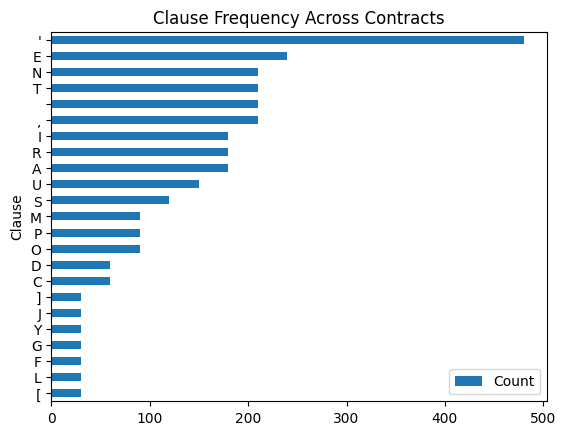

In [22]:
clause_df.sort_values("Count").plot(
    x="Clause",
    y="Count",
    kind="barh"
)

plt.title("Clause Frequency Across Contracts")

plt.show()

# Obligation Analysis

### Objective

Contractual obligations represent legally enforceable actions that parties must perform.

Examples include:

- Making payments
- Maintaining insurance
- Fulfilling contractual responsibilities

Obligation analysis provides deeper insight into contract behavior and moves beyond simple metadata extraction toward semantic understanding of legal documents.

This is a core component of modern Contract Intelligence systems.

In [23]:
df["obligations"].iloc[0]

"['CLAUSE THREE – PAYMENT: The BORROWER shall pay monthly installments, increased by', 'CLAUSE FIVE – INSURANCE: The BORROWER must contract mandatory insurance for the']"

In [24]:
import ast

df["obligations"] = df["obligations"].apply(ast.literal_eval)

In [25]:
type(df["obligations"].iloc[0])

list

In [26]:
all_obligations = []

for obligation_list in df["obligations"]:
    all_obligations.extend(obligation_list)

len(all_obligations)

60

In [27]:
all_obligations[:10]

['CLAUSE THREE – PAYMENT: The BORROWER shall pay monthly installments, increased by',
 'CLAUSE FIVE – INSURANCE: The BORROWER must contract mandatory insurance for the',
 'CLAUSE THREE – PAYMENT: The BORROWER shall pay monthly installments, increased by',
 'CLAUSE FIVE – INSURANCE: The BORROWER must contract mandatory insurance for the',
 'CLAUSE THREE – PAYMENT: The BORROWER shall pay monthly installments, increased by',
 'CLAUSE FIVE – INSURANCE: The BORROWER must contract mandatory insurance for the',
 'CLAUSE THREE – PAYMENT: The BORROWER shall pay monthly installments, increased by',
 'CLAUSE FIVE – INSURANCE: The BORROWER must contract mandatory insurance for the',
 'CLAUSE THREE – PAYMENT: The BORROWER shall pay monthly installments, increased by',
 'CLAUSE FIVE – INSURANCE: The BORROWER must contract mandatory insurance for the']

In [28]:
from collections import Counter

obligation_counts = Counter(all_obligations)

obligation_counts

Counter({'CLAUSE THREE – PAYMENT: The BORROWER shall pay monthly installments, increased by': 30,
         'CLAUSE FIVE – INSURANCE: The BORROWER must contract mandatory insurance for the': 30})

In [29]:
# Dataframe
obligation_df = pd.DataFrame(
    obligation_counts.items(),
    columns=["Obligation", "Count"]
)

obligation_df

,Obligation,Count
0,CLAUSE THREE – PAYMENT: The BORROWER shall pay...,30
1,CLAUSE FIVE – INSURANCE: The BORROWER must con...,30


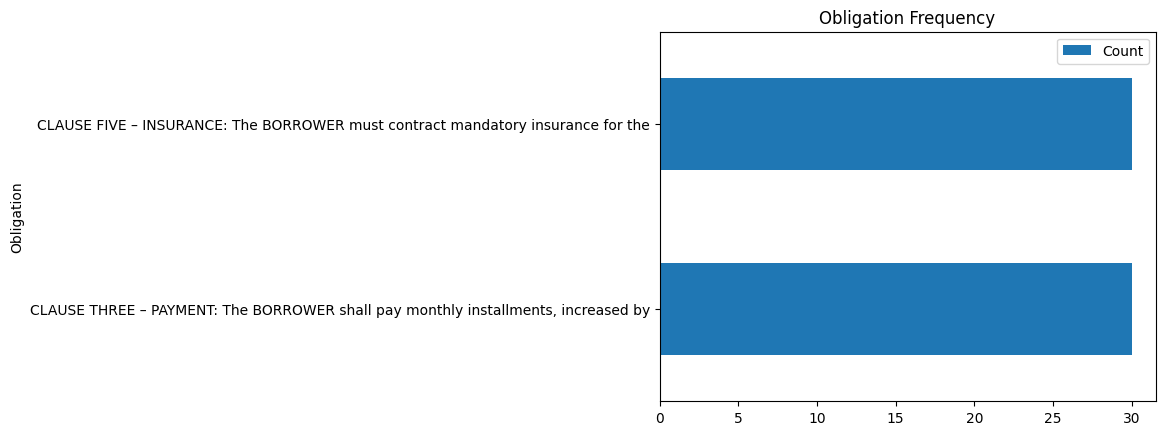

In [30]:
obligation_df.plot(
    x="Obligation",
    y="Count",
    kind="barh"
)

plt.title("Obligation Frequency")

plt.show()

# Risk Analysis

In [31]:
df["risk_score"] = (
    df["clauses"].apply(
        lambda x:
        ("DEFAULT" in str(x))
        + ("TERMINATION" in str(x))
        + ("GUARANTEES" in str(x))
    )
)

df[["contract_type", "risk_score"]].head()

,contract_type,risk_score
0,HEALTH FINANCING AGREEMENT,3
1,MOTORCYCLE FINANCING AGREEMENT,3
2,HEALTH FINANCING AGREEMENT,3
3,STUDENT LOAN AGREEMENT,3
4,HEALTH FINANCING AGREEMENT,3


Although all contracts receive the same score due to the standardized dataset structure, this demonstrates a simple rule-based risk scoring framework that can be extended to real-world legal documents.

# Executive Dashboard Summary

In [32]:
summary = pd.DataFrame({
    "Metric": [
        "Total Contracts",
        "Unique Borrowers",
        "Contract Types",
        "Average Amount",
        "Maximum Amount",
        "Minimum Amount"
    ],
    "Value": [
        len(df),
        df["borrower"].nunique(),
        df["contract_type"].nunique(),
        round(df["amount_clean"].mean(), 2),
        df["amount_clean"].max(),
        df["amount_clean"].min()
    ]
})

summary

,Metric,Value
0,Total Contracts,30.00
1,Unique Borrowers,10.00
2,Contract Types,5.00
3,Average Amount,248891.87
4,Maximum Amount,1203432.00
5,Minimum Amount,33310.00


# Business Insights

## Key Observations

1. Car Financing Agreements represent the largest contract category.

2. Real Estate Financing Agreements contain substantially larger financing amounts than all other agreement types.

3. All contracts share an identical legal clause structure, indicating a highly standardized contract generation process.

4. Payment and Insurance obligations appear consistently across all agreements.

5. The structured nature of the dataset makes it suitable for contract intelligence and future machine learning applications.

# Key Findings and Conclusions

## Major Findings

### Dataset Characteristics

The dataset contains 30 synthetic financing agreements distributed across five financing categories.

The contracts were generated using a highly standardized template structure.

---

### Financing Amount Analysis

Financing amounts vary significantly across contract types.

Real Estate Financing Agreements contain financing amounts exceeding one million dollars, while most other financing categories fall within the range of approximately $30,000 to $90,000.

This creates a right-skewed distribution where the mean financing amount is substantially larger than the median.

---

### Clause Analysis

All contracts contain the same legal clause structure:

- Purpose
- Term
- Payment
- Guarantees
- Insurance
- Default
- Termination
- Jurisdiction

This indicates a highly standardized contract generation process.

---

### Obligation Analysis

Two primary obligations appear consistently across all contracts:

- Payment Obligations
- Insurance Obligations

These obligations represent the core responsibilities imposed on borrowers within the financing agreements.

---
## Conclusion

The exploratory analysis demonstrates that the dataset is highly structured and consistent.

The contract intelligence pipeline successfully transformed unstructured PDF contracts into a structured analytical dataset containing metadata, legal clauses, jurisdiction information, and contractual obligations.

The resulting dataset is suitable for downstream analytics, legal NLP applications, and future machine learning experiments.

---

## Future Work

Potential future enhancements include:

- Risk Assessment
- Clause Classification
- Contract Summarization
- Named Entity Recognition (NER)
- Machine Learning-based Information Extraction
- LLM-powered Contract Intelligence Systems